<a target="_blank" href="https://colab.research.google.com/github/lukebarousse/Python_Data_Analytics_Course/blob/main/4_Problems/2_20_Seaborn Intro.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

## 🟩 Top Companies Bar Plot (2.20.1)

/var/folders/74/_sq0tgl174q5j9qsr6fx81lc0000gn/T/ipykernel_95614/4106752633.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_new.reset_index(), x='salary_year_avg', y='company_name', palette='viridis')


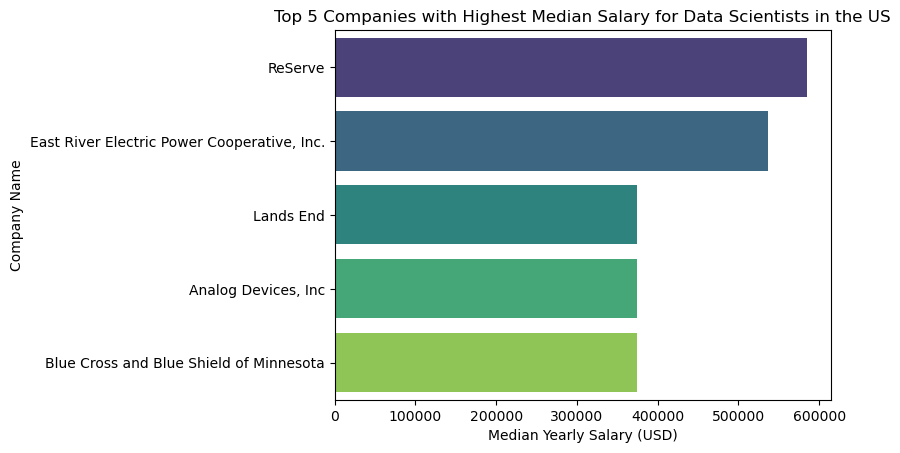

In [8]:
import seaborn as sns
df_new = df[(df['job_title_short']=='Data Scientist') & (df['job_country'] == 'United States')].copy()
df_new = df_new.groupby('company_name')['salary_year_avg'].median().sort_values(ascending=False).head(5)
sns.barplot(data=df_new.reset_index(), x='salary_year_avg', y='company_name', palette='viridis')
plt.title('Top 5 Companies with Highest Median Salary for Data Scientists in the US')
plt.xlabel('Median Yearly Salary (USD)')
plt.ylabel('Company Name')
plt.show()

---

## 🟨 Data Scientist Salary Histogram (2.20.2)

Text(0, 0.5, 'Number of Jobs')

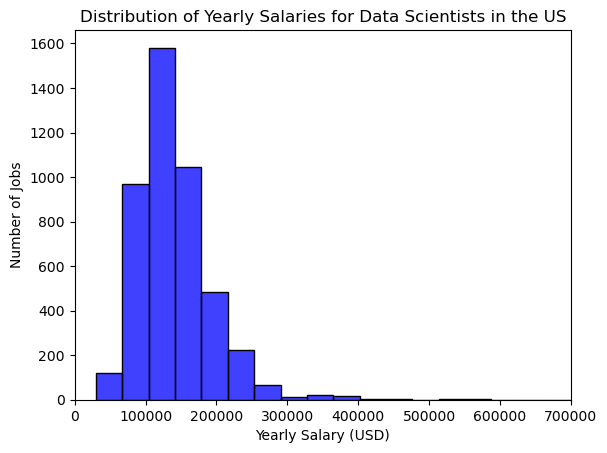

In [14]:
import seaborn as sns
df_new = df[(df['job_title_short']=='Data Scientist') & (df['job_country'] == 'United States')].copy().dropna(subset=['salary_year_avg'])
sns.histplot(df_new['salary_year_avg'], bins=25, kde=False, color='blue')
plt.xlim(0, 700000)
plt.title('Distribution of Yearly Salaries for Data Scientists in the US')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('Number of Jobs')

---

## 🟨 Data Roles Salary Box Plot (2.20.3)

Text(0.5, 1.0, 'Yearly Salary Comparison for Data Roles in India')

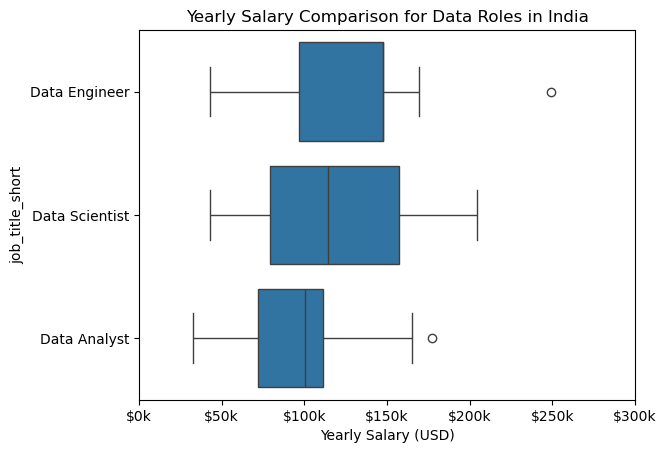

In [26]:
# Code Needed
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']
df_india = df[df['job_title_short'].isin(job_titles) & (df['job_country'] == 'India')]
df_india = df_india.dropna(subset=['salary_year_avg'])
sns.boxplot(data=df_india, x='salary_year_avg', y='job_title_short')
plt.xlim(0, 300000)
plt.xlabel('Yearly Salary (USD)')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))
plt.title('Yearly Salary Comparison for Data Roles in India')

---

## 🟨 Salary Distribution for United States (2.20.4)

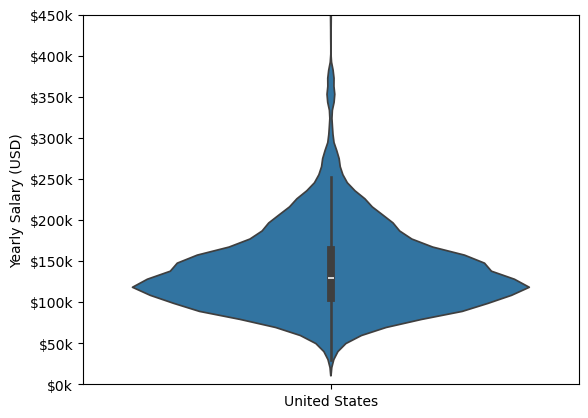

In [29]:
import seaborn as sns
df_new = df[(df['job_title_short']=='Data Scientist') & (df['job_country'] == 'United States')].copy().dropna(subset=['salary_year_avg'])
sns.violinplot(data=df_new, x='job_country', y='salary_year_avg')
plt.xlabel('')
plt.ylabel('Yearly Salary (USD)')
plt.ylim(0, 450000) 
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))


---